In [23]:
# pip install torch torchvision scikit-learn matplotlib seaborn tqdm

import os, random, copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset, Subset
import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18

from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    roc_curve, classification_report
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cpu


In [24]:
DATA_ROOT = Path('./data')
SAMPLES_PER_PARTITION = 5000

base_transform = T.Compose([
    T.ToTensor(),
])

mnist_train = torchvision.datasets.MNIST(DATA_ROOT, train=True,  download=True, transform=base_transform)
mnist_test  = torchvision.datasets.MNIST(DATA_ROOT, train=False, download=True, transform=base_transform)
print(f'Train: {len(mnist_train)}, Test: {len(mnist_test)}')

Train: 60000, Test: 10000


In [25]:
def attack_gaussian_noise(img: torch.Tensor, std: float = 0.15) -> torch.Tensor:
    return (img + torch.randn_like(img) * std).clamp(0, 1)


def attack_salt_pepper(img: torch.Tensor, prob: float = 0.10) -> torch.Tensor:
    out = img.clone()
    mask = torch.rand_like(img)
    out[mask < prob / 2]  = 0.0
    out[mask > 1 - prob / 2] = 1.0
    return out


def attack_geometric(img: torch.Tensor, magnitude: float = 6.0) -> torch.Tensor:
    transform = T.ElasticTransform(alpha=magnitude * 50, sigma=magnitude)
    return transform(img)


def attack_blending(img: torch.Tensor, alpha: float = 0.25) -> torch.Tensor:
    pattern = torch.rand_like(img)
    return ((1 - alpha) * img + alpha * pattern).clamp(0, 1)


def attack_trigger(img: torch.Tensor, trigger_size: int = 5) -> torch.Tensor:
    out = img.clone()
    H, W = img.shape[-2], img.shape[-1]
    x = random.randint(0, W - trigger_size)
    y = random.randint(0, H - trigger_size)
    out[:, y:y+trigger_size, x:x+trigger_size] = 1.0
    return out


ATTACKS = {
    'attack_a': attack_gaussian_noise,
    'attack_b': attack_salt_pepper,
    'attack_c': attack_geometric,
    'attack_d': attack_blending,
    'attack_e': attack_trigger,
}

In [26]:
class AnomalyPartition(Dataset):
    def __init__(self, base_dataset, indices, attack_fn=None):
        self.base = base_dataset
        self.indices = indices
        self.attack_fn = attack_fn  # None → clean
        self.label = 0 if attack_fn is None else 1

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, _ = self.base[self.indices[idx]]
        if self.attack_fn is not None:
            img = self.attack_fn(img)
        return img, self.label


def make_partitions(base_dataset, n=SAMPLES_PER_PARTITION, seed=SEED):
    """Losuje rozłączne indeksy dla clean + każdego ataku."""
    rng = np.random.default_rng(seed)
    total_needed = n * (1 + len(ATTACKS))
    assert total_needed <= len(base_dataset), 'Za mało próbek w zbiorze!'
    all_idx = rng.permutation(len(base_dataset))[:total_needed]
    splits = np.array_split(all_idx, 1 + len(ATTACKS))

    partitions = {'clean': AnomalyPartition(base_dataset, splits[0].tolist(), None)}
    for i, (name, fn) in enumerate(ATTACKS.items()):
        partitions[name] = AnomalyPartition(base_dataset, splits[i+1].tolist(), fn)
    return partitions


parts_train = make_partitions(mnist_train)
parts_test  = make_partitions(mnist_test, n=1000)

print('Partycje treningowe:')
for k, v in parts_train.items():
    print(f'  {k}: {len(v)} próbek, label={v.label}')

Partycje treningowe:
  clean: 5000 próbek, label=0
  attack_a: 5000 próbek, label=1
  attack_b: 5000 próbek, label=1
  attack_c: 5000 próbek, label=1
  attack_d: 5000 próbek, label=1
  attack_e: 5000 próbek, label=1


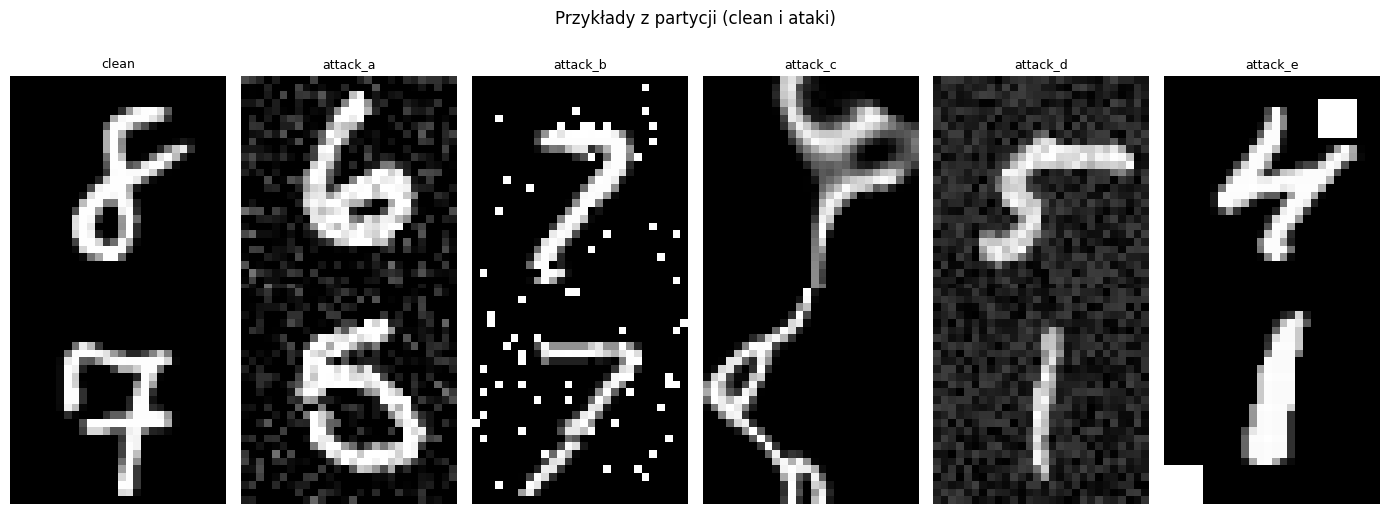

In [27]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for col, (name, part) in enumerate(list(parts_train.items())[:6]):
    img, lbl = part[0]
    axes[0, col].imshow(img.squeeze(), cmap='gray')
    axes[0, col].set_title(name, fontsize=9)
    axes[0, col].axis('off')
    img2, _ = part[1]
    axes[1, col].imshow(img2.squeeze(), cmap='gray')
    axes[1, col].axis('off')
plt.suptitle('Przykłady z partycji (clean i ataki)', y=1.02)
plt.tight_layout()
plt.savefig('partition_examples.png', dpi=120, bbox_inches='tight')
plt.show()

In [28]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 1), 
        )

    def forward(self, x):
        return self.classifier(self.features(x))

## 3. Funkcje treningu i ewaluacji

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.float().to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        preds = (logits > 0).float()
        correct += (preds == labels).sum().item()
        n += len(labels)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs).squeeze(1).cpu()
        all_logits.append(logits)
        all_labels.append(labels)
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs  = torch.sigmoid(torch.tensor(logits)).numpy()
    preds  = (probs > 0.5).astype(int)

    auroc = roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else float('nan')
    f1    = f1_score(labels, preds, zero_division=0)

    fpr, tpr, _ = roc_curve(labels, probs) if len(np.unique(labels)) > 1 else ([0],[1],None)
    idx = np.searchsorted(tpr, 0.95)

    return {'auroc': auroc, 'f1': f1, 'probs': probs, 'labels': labels, 'preds': preds}


def train_model(train_dataset, n_epochs=10, batch_size=128, lr=1e-3, class_weight=None):
    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
    model = MODEL_CLASS().to(DEVICE)
    pos_weight = torch.tensor([class_weight]).to(DEVICE) if class_weight else None
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    history = []
    for epoch in tqdm(range(1, n_epochs+1), desc='Training'):
        loss, acc = train_epoch(model, loader, optimizer, criterion)
        scheduler.step()
        history.append({'epoch': epoch, 'loss': loss, 'acc': acc})
    return model, history


## 4. Krok 1 — klasyfikator binarny (clean + attack_a → test na attack_b)

Trening Krok 1: 10000 próbek


Training:   0%|          | 0/15 [00:00<?, ?it/s]

Training: 100%|██████████| 15/15 [03:05<00:00, 12.38s/it]


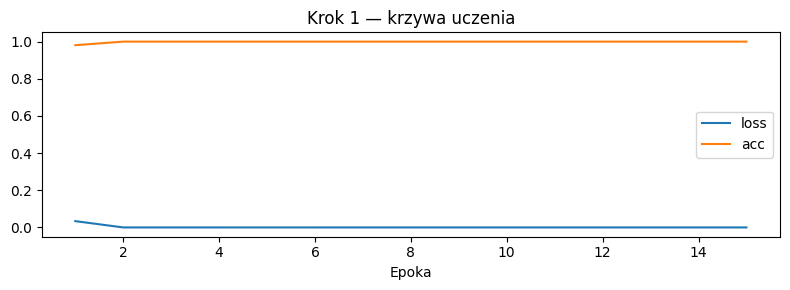

In [30]:
train_step1 = ConcatDataset([parts_train['clean'], parts_train['attack_a']])
print(f'Trening Krok 1: {len(train_step1)} próbek')

model_step1, hist1 = train_model(train_step1, n_epochs=15)

plt.figure(figsize=(8, 3))
epochs = [h['epoch'] for h in hist1]
plt.plot(epochs, [h['loss'] for h in hist1], label='loss')
plt.plot(epochs, [h['acc']  for h in hist1], label='acc')
plt.xlabel('Epoka'); plt.legend(); plt.title('Krok 1 — krzywa uczenia')
plt.tight_layout(); plt.savefig('step1_training.png', dpi=120); plt.show()

In [ ]:
results_step1 = {}

for attack_name in ['attack_a', 'attack_b', 'attack_c', 'attack_d', 'attack_e']:
    test_ds = ConcatDataset([parts_test['clean'], parts_test[attack_name]])
    loader  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0)
    metrics = evaluate(model_step1, loader)
    results_step1[attack_name] = metrics
    print(f'{attack_name}: AUROC={metrics["auroc"]:.3f}  F1={metrics["f1"]:.3f}')

print('\n--- Znany atak (attack_a) vs Nieznany (attack_b) ---')
for k in ['attack_a', 'attack_b']:
    m = results_step1[k]
    print(f'{k}: AUROC={m["auroc"]:.3f}, F1={m["f1"]:.3f}')

attack_a: AUROC=1.000  F1=1.000  FPR@95=0.000
attack_b: AUROC=1.000  F1=1.000  FPR@95=0.000
attack_c: AUROC=0.413  F1=0.002  FPR@95=0.952
attack_d: AUROC=1.000  F1=0.944  FPR@95=0.000
attack_e: AUROC=0.705  F1=0.000  FPR@95=0.815

--- Znany atak (attack_a) vs Nieznany (attack_b) ---
attack_a: AUROC=1.000, F1=1.000
attack_b: AUROC=1.000, F1=1.000


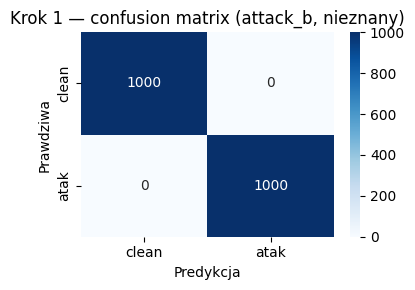

In [31]:
m = results_step1['attack_b']
cm = confusion_matrix(m['labels'], m['preds'])
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['clean','atak'], yticklabels=['clean','atak'])
plt.title('Krok 1 — confusion matrix (attack_b, nieznany)')
plt.ylabel('Prawdziwa'); plt.xlabel('Predykcja')
plt.tight_layout(); plt.savefig('step1_cm_attackb.png', dpi=120); plt.show()

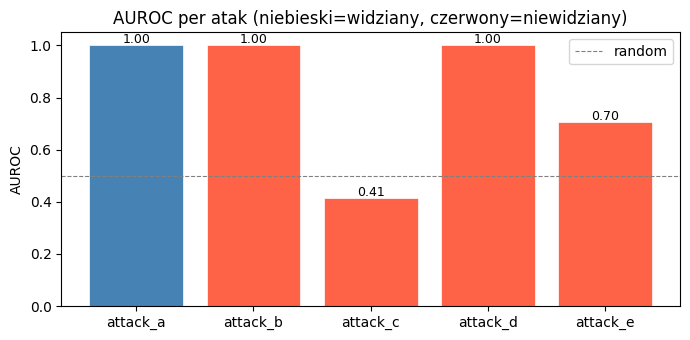

In [32]:
attacks = list(results_step1.keys())
aurocs  = [results_step1[a]['auroc'] for a in attacks]
colors  = ['steelblue' if a == 'attack_a' else 'tomato' for a in attacks]

plt.figure(figsize=(7, 3.5))
bars = plt.bar(attacks, aurocs, color=colors, edgecolor='white', linewidth=0.5)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='random')
plt.ylim(0, 1.05)
plt.ylabel('AUROC')
plt.title('AUROC per atak (niebieski=widziany, czerwony=niewidziany)')
plt.legend()
for bar, val in zip(bars, aurocs):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('step1_auroc.png', dpi=120); plt.show()

## trening na A₁…Aₙ, test na Aₙ₊₁

In [33]:
UNSEEN_ATTACK = 'attack_e' 
SEEN_ATTACKS  = ['attack_a', 'attack_b', 'attack_c', 'attack_d']

test_ds_unseen = ConcatDataset([parts_test['clean'], parts_test[UNSEEN_ATTACK]])
test_loader_unseen = DataLoader(test_ds_unseen, batch_size=256, shuffle=False, num_workers=0)

generalization_results = []

for k in range(1, len(SEEN_ATTACKS) + 1):
    used_attacks = SEEN_ATTACKS[:k]
    train_parts  = [parts_train['clean']] + [parts_train[a] for a in used_attacks]
    train_ds     = ConcatDataset(train_parts)

    print(f'\nTrening na: clean + {used_attacks}')
    model_k, _ = train_model(train_ds, n_epochs=10)

    metrics = evaluate(model_k, test_loader_unseen)
    generalization_results.append({
        'n_attacks': k,
        'used': used_attacks.copy(),
        **{key: metrics[key] for key in ['auroc', 'f1', 'fpr95']}
    })
    print(f'AUROC={metrics["auroc"]:.3f}, F1={metrics["f1"]:.3f}')


Trening na: clean + ['attack_a']


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Training: 100%|██████████| 10/10 [02:05<00:00, 12.55s/it]


AUROC=0.709, F1=0.000

Trening na: clean + ['attack_a', 'attack_b']


Training: 100%|██████████| 10/10 [03:03<00:00, 18.33s/it]


AUROC=0.717, F1=0.000

Trening na: clean + ['attack_a', 'attack_b', 'attack_c']


Training: 100%|██████████| 10/10 [05:56<00:00, 35.67s/it]


AUROC=0.485, F1=0.076

Trening na: clean + ['attack_a', 'attack_b', 'attack_c', 'attack_d']


Training: 100%|██████████| 10/10 [07:11<00:00, 43.11s/it]


AUROC=0.508, F1=0.150


## Pythia, analogiczny pipeline

In [34]:
from torchvision.datasets import ImageFolder
from torchvision import transforms as TF

PYTHIA_ROOT = Path('./pythia')

def load_pythia_partition(partition_dir: Path, label: int, img_size: int = 70):
    transform = TF.Compose([
        TF.Grayscale(num_output_channels=1),
        TF.Resize((img_size, img_size)),
        TF.ToTensor(),
    ])

    class FlatFolderDataset(Dataset):
        def __init__(self, folder, transform, label):
            self.files = sorted(folder.glob('*.png')) + sorted(folder.glob('*.jpg'))
            self.transform = transform
            self.label = label
        def __len__(self): 
            return len(self.files)
        
        def __getitem__(self, idx):
            from PIL import Image
            img = Image.open(self.files[idx])
            return self.transform(img), self.label

    return FlatFolderDataset(partition_dir, transform, label)


if PYTHIA_ROOT.exists():
    pythia_clean = load_pythia_partition(PYTHIA_ROOT / 'clean', label=0)
    pythia_attacks = {}
    for attack_dir in sorted(PYTHIA_ROOT.iterdir()):
        if attack_dir.is_dir() and attack_dir.name != 'clean':
            pythia_attacks[attack_dir.name] = load_pythia_partition(attack_dir, label=1)

In [35]:
if PYTHIA_ROOT.exists() and 'attack_a' in pythia_attacks and 'attack_b' in pythia_attacks:

    def split_dataset(ds, train_frac=0.8, seed=SEED):
        n = len(ds)
        idx = np.random.default_rng(seed).permutation(n)
        split = int(n * train_frac)
        return Subset(ds, idx[:split].tolist()), Subset(ds, idx[split:].tolist())

    py_clean_tr, py_clean_te   = split_dataset(pythia_clean)
    py_atk_a_tr, py_atk_a_te  = split_dataset(pythia_attacks['attack_a'])
    py_atk_b_tr, py_atk_b_te  = split_dataset(pythia_attacks['attack_b'])

    train_py1 = ConcatDataset([py_clean_tr, py_atk_a_tr])
    model_py1, _ = train_model(train_py1, n_epochs=15)

    test_py1 = ConcatDataset([py_clean_te, py_atk_b_te])
    loader_py1 = DataLoader(test_py1, batch_size=128, shuffle=False)
    m_py1 = evaluate(model_py1, loader_py1)
    print(f'Pythia Krok 1 (test attack_b): AUROC={m_py1["auroc"]:.3f}, F1={m_py1["f1"]:.3f}')
    print(classification_report(m_py1['labels'], m_py1['preds'], target_names=['clean','atak']))

Training:   0%|          | 0/15 [00:00<?, ?it/s]

Training: 100%|██████████| 15/15 [02:13<00:00,  8.88s/it]


Pythia Krok 1 (test attack_b): AUROC=0.521, F1=0.499
              precision    recall  f1-score   support

       clean       0.50      0.51      0.51       200
        atak       0.50      0.49      0.50       200

    accuracy                           0.50       400
   macro avg       0.50      0.50      0.50       400
weighted avg       0.50      0.50      0.50       400



In [36]:
UNSEEN_ATTACK = 'attack_e'  
SEEN_ATTACKS  = ['attack_a', 'attack_b', 'attack_c', 'attack_d']

test_ds_unseen = ConcatDataset([parts_test['clean'], parts_test[UNSEEN_ATTACK]])
test_loader_unseen = DataLoader(test_ds_unseen, batch_size=256, shuffle=False, num_workers=0)

generalization_results = []

for k in range(1, len(SEEN_ATTACKS) + 1):
    used_attacks = SEEN_ATTACKS[:k]
    train_parts  = [parts_train['clean']] + [parts_train[a] for a in used_attacks]
    train_ds     = ConcatDataset(train_parts)

    print(f'\nTrening na: clean + {used_attacks}')
    model_k, _ = train_model(train_ds, n_epochs=10)

    metrics = evaluate(model_k, test_loader_unseen)
    generalization_results.append({
        'n_attacks': k,
        'used': used_attacks.copy(),
        **{key: metrics[key] for key in ['auroc', 'f1']}
    })
    print(f'AUROC={metrics["auroc"]:.3f}, F1={metrics["f1"]:.3f}')


Trening na: clean + ['attack_a']


Training: 100%|██████████| 10/10 [02:01<00:00, 12.17s/it]


AUROC=0.707, F1=0.000

Trening na: clean + ['attack_a', 'attack_b']


Training: 100%|██████████| 10/10 [03:08<00:00, 18.86s/it]


AUROC=0.784, F1=0.000

Trening na: clean + ['attack_a', 'attack_b', 'attack_c']


Training: 100%|██████████| 10/10 [06:13<00:00, 37.33s/it]


AUROC=0.488, F1=0.091

Trening na: clean + ['attack_a', 'attack_b', 'attack_c', 'attack_d']


Training: 100%|██████████| 10/10 [07:08<00:00, 42.89s/it]


AUROC=0.520, F1=0.133
